# **LAB 01**

### Metodo del data blocking

Un aspetto fondamentale in ogni simulazione Monte Carlo è la corretta valutazione dell’incertezza statistica associata alle quantità misurate. Una stima affidabile dell’errore è essenziale per interpretare i risultati e verificare la convergenza dei valori ottenuti.

Nel caso generale, data una quantità osservabile $A$, la sua varianza è definita come:

$$ \sigma_A^2 = \langle A^2 \rangle - \langle A \rangle^2$$ 

Tuttavia, in una simulazione Monte Carlo le quantità non sono note analiticamente e devono essere stimate a partire dai dati generati numericamente. Per questo motivo si utilizza il metodo del data blocking, che permette di ridurre le correlazioni tra misure successive e ottenere una stima più robusta dell’errore statistico.

L’idea centrale consiste nel suddividere il numero totale di misure Monte Carlo (ad esempio $M$ step) in $N$ blocchi indipendenti, ciascuno contenente $\frac{M}{N}$ campioni. All’interno di ogni blocco si calcola una stima locale dell’osservabile, indicata con $A_i$, con $i = 1, \dots, N$. In questo modo si ottiene un insieme di valori medi di blocco, considerabili indipendenti. A partire da questi valori è possibile stimare le quantità:

$$ \langle A \rangle \simeq \frac{1}{N} \sum_{i=1}^{N} A_i,
\qquad
\langle A^2 \rangle \simeq \frac{1}{N} \sum_{i=1}^{N} A_i^2 $$

Da queste relazioni si ricava la stima della varianza della media:

$$ \sigma_{\langle A \rangle} = \sqrt{\frac{1}{N-1}
\left[
\frac{1}{N} \sum_{i=1}^{N} A_i^2 -
\left(\frac{1}{N} \sum_{i=1}^{N} A_i \right)^2
\right]}$$ 

Questo approccio consente di ottenere, in modo progressivo durante la simulazione, sia la stima dell’osservabile sia la sua incertezza statistica. In particolare, dopo ogni blocco è possibile aggiornare la media cumulativa e la relativa deviazione standard, monitorando così la convergenza del risultato.

È importante sottolineare che la scelta del numero di blocchi $N$ non è arbitraria. Se $N$ è troppo piccolo, si ottengono poche stime indipendenti e quindi un errore statistico poco affidabile. Al contrario, se $N$ è troppo grande, il numero di campioni per blocco diventa insufficiente e le stime dei singoli $A_i$ risultano molto rumorose, aumentando artificialmente la varianza. La scelta ottimale rappresenta quindi un compromesso tra indipendenza statistica e buona risoluzione interna dei blocchi.


### Teorema del limite centrale
Il teorema del limite centrale afferma che, data una popolazione caratterizzata da una media $\mu$ e da una varianza finita $\sigma^2$, la distribuzione della media campionaria tende ad assumere una forma normale all'aumentare della numerosità del campione, indipendentemente dalla distribuzione originaria della popolazione. Di conseguenza, per campioni sufficientemente ampi, la distribuzione delle medie campionarie può essere approssimata mediante una distribuzione normale con media uguale a quella della popolazione e deviazione standard pari a $\frac{\sigma}{\sqrt{N}}$, dove $N$ rappresenta la dimensione del campione.


## **Esercizio 1.1**

In questo esercizio viene testato il generatore di numeri casuali fornito. Sebbene questi numeri siano definiti “casuali”, in realtà sono prodotti da un algoritmo deterministico: per questo motivo, è necessario verificare se le loro proprietà statistiche siano compatibili con quelle di una distribuzione uniforme nell’intervallo $[0,1]$. 
Per fare ciò si utilizzano tre controlli statistici complementari:
1. stima del valor medio $\braket{r}$
2. stima della varianza $\sigma^2$
3. test del $\chi^2$ di Pearson

Tutte le quantità vengono calcolate utilizzando il metodo dei blocchi, che permette di stimare correttamente le incertezze statistiche in presenza di possibili correlazioni tra i dati.

#### STIMA DEL VALOR MEDIO $\braket{r}$
Innanzitutto, si vuole verificare che $\braket{r} = \int_0^1 r dr = \frac{1}{2}$: infatti, se il generatore funziona correttamente, il valor medio campionario dei numeri deve convergere a 0.5. 

A tal fine, si generano $M=1 \cdot 10^6$ estrazioni divise in $N=100$ blocchi; viene poi calcolata la media per ogni blocco e infine viene stimata l'incertezza statistica tramite la deviazione standard della media. L'errore si riduce a: 

$$ \sigma_{\braket{r}} = \frac{\sigma}{\sqrt{N_{blocchi}}}$$

Come è possibile osservare nei grafici riportati qui sotto, il valor medio converge verso 0.5; inoltre, l'errore diminuisce all'aumentare il numero di blocchi, scalando come $\frac{1}{\sqrt{N}}$ (come previsto dal teorema del limite centrale). 

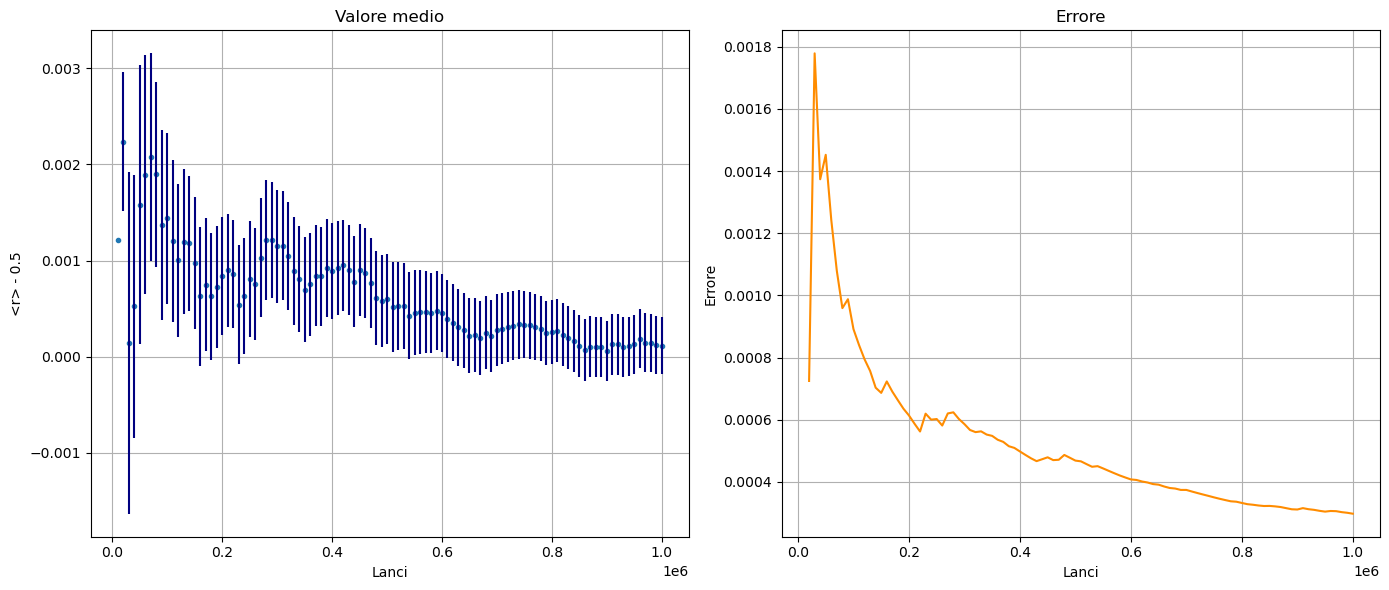

In [24]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("esercizio1.1/data.dat")

x = data[:, 0]
y = data[:, 1] - 0.5
error = data[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PLOT VALOR MEDIO
axes[0].plot(x, y, ".")
axes[0].errorbar(x, y, yerr=error, color="navy", linestyle="none")
axes[0].set_xlabel("Lanci")
axes[0].set_ylabel("<r> - 0.5")
axes[0].set_title("Valore medio")
axes[0].grid(True)

# PLOT ERRORE
axes[1].errorbar(x, error, marker='', linestyle='-', color='darkorange')
axes[1].set_xlabel("Lanci")
axes[1].set_ylabel("Errore")
axes[1].set_title("Errore")
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### STIMA DELLA VARIANZA

Per una variabile casuale $r$, la varianza è definita come $\sigma^2 = \braket{(r-\braket{r})^2}$. Nel caso di una distribuzione uniforme si ha che $\braket{r}=\frac{1}{2}$ e quindi la definizione diventa $\sigma^2 = \braket{(r-\frac{1}{2})^2}$. Dunque, bisogna verificare che $\sigma^2 = \int_0^1 (r-1/2)^2 dr = \frac{1}{12}$. 

Procedendo in modo analogo a quanto fatto nel punto precedente, tramite la media a blocchi si ottengono i risultati riportati qui sotto. Come da aspettativa, si osserva la convergenza a $\frac{1}{12}$ e una diminuzione delle fluttuazioni al crescere dei blocchi che scala come $\frac{1}{\sqrt{N}}$. 

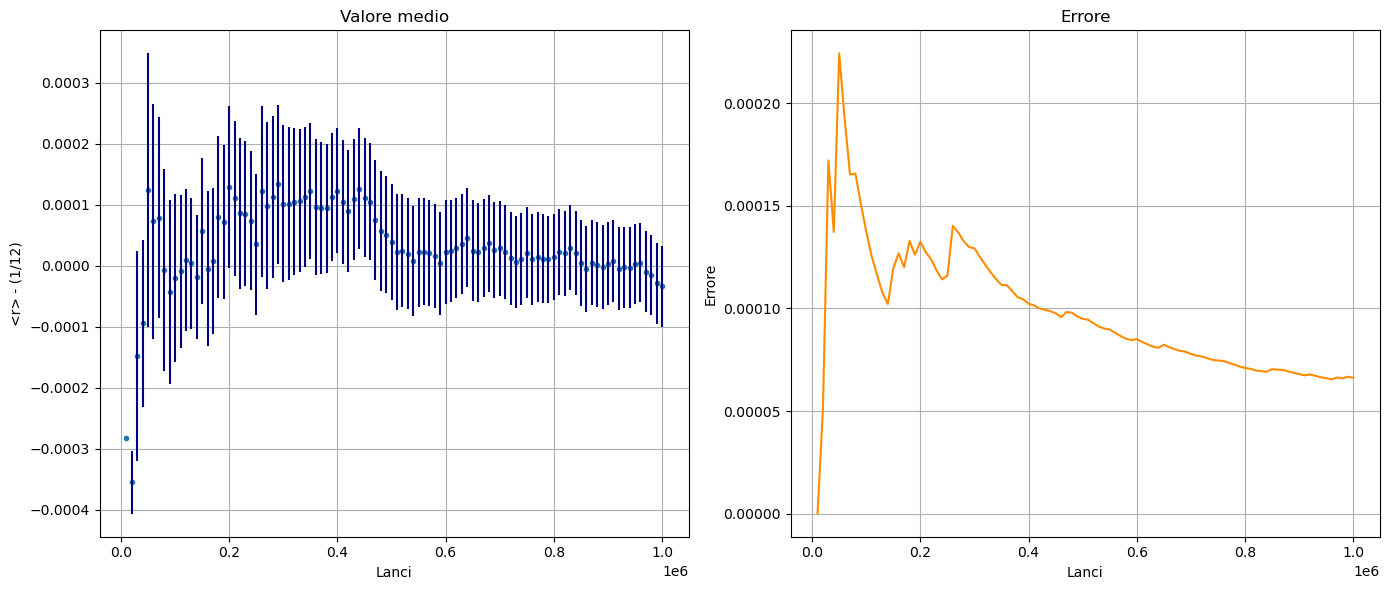

In [26]:
data = np.loadtxt("esercizio1.1/data2.dat")

x=data[:,0]
y=data[:,1]-(1/12)
error=data[:,2]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PLOT VALOR MEDIO
axes[0].plot(x, y, ".")
axes[0].errorbar(x, y, yerr=error, color="navy", linestyle="none")
axes[0].set_xlabel("Lanci")
axes[0].set_ylabel("<r> - (1/12)")
axes[0].set_title("Valore medio")
axes[0].grid(True)

# PLOT ERRORE
axes[1].errorbar(x, error, marker='', linestyle='-', color='darkorange')
axes[1].set_xlabel("Lanci")
axes[1].set_ylabel("Errore")
axes[1].set_title("Errore")
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### TEST DEL $\chi^2$ DI PEARSON
Nei punti precedenti si è verificato il valor medio e la varianza del generatore pseudo-casuale. Tuttavia, questi controlli non sono sufficienti per garantire che l’intera distribuzione dei numeri sia realmente uniforme. Per questo motivo, si utilizza un test statistico più globale, ovvero il test $\chi^2$ di Pearson.

L'idea è quella di confrontare il numero di eventi osservati in ciascun intervallo con il numero di eventi attesi nel caso di distribuzione uniforme. Dunque, si divide l'intervallo $[0,1]$ in $M=100$ sotto-intervalli uguali. Se i numeri sono distribuiti uniformemente, ogni intervallo deve contenere in media $E_i = \frac{n}{M}$, dove $n$ è il numero totale di estrazioni e $M$ è il numero di intervalli. Il chi quadro è definito come: 

$$ \chi^2 = \sum_{i=1}^M \frac{(n_i-\frac{n}{M})}{\frac{n}{M}} $$

dove $n_i$ è il numero di eventi osservati nell'$i$-esimo bin, mentre $\frac{n}{M}$ è il numero atteso di eventi. 

La quantità $\chi^2$ misura quindi quanto le osservazioni si discostano dal comportamento atteso. Se $\chi^2$ è vicino a $M$, le fluttuazioni sono compatibili con quelle statistiche attese; invece, se $\chi^2$ è molto grande, la distribuzione osservata è difficilmente compatibile con una distribuzione uniforme. Poiché $M=100$, ci si apetta $\chi^2 \approx 100$.  

/var/folders/hk/m208pmmx00x65fd45c2b1xwh0000gn/T/ipykernel_68729/4015987798.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x, chi2.pdf(x, gdl), 'r-', lw=2, label=f'Chi2 teorica (df={gdl})', color = 'gold')


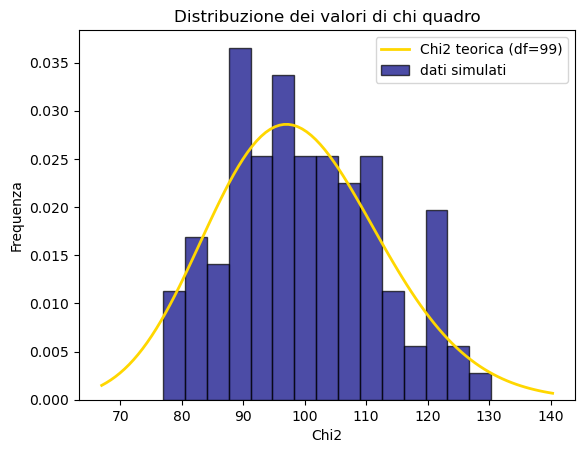

media = 99.7964
deviazione standard = 12.355598692090966


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

data_chi2 = np.loadtxt("esercizio1.1/data_chi.dat")
gdl = 99


x = np.linspace(min(data_chi2)-10, max(data_chi2)+10, 100)
plt.plot(x, chi2.pdf(x, gdl), 'r-', lw=2, label=f'Chi2 teorica (df={gdl})', color = 'gold')
plt.hist(data_chi2,
         bins=15,
         density=True,
         alpha=0.7,
         color='navy',
         edgecolor='black', 
         label = 'dati simulati')
plt.xlabel("Chi2")
plt.ylabel("Frequenza")
plt.title("Distribuzione dei valori di chi quadro")

plt.legend()
plt.show()

print("media =", np.mean(data_chi2))
print("deviazione standard =", np.std(data_chi2))

Osservando il grafico e i valori stampati, è possibile concludere che l'istogramma dei 100 valori di $\chi^2$ ottenuti è compatibile con la distribuzione teorica del chi-quadro con 99 gradi di libertà: infatti, la curva teorica descrive correttamente la posizione del massimo e la larghezza della distribuzione osservata. La media dei valori ottenuti risulta essere $\langle \chi^2 \rangle = 99.80$, in ottimo accordo con il valore teorico atteso.


## **Esercizio 1.2**

In questo esercizio viene esteso il generatore di numeri pseudo-casuali dell'esercizio precedente, introducendo la possibilità di campionare variabili casuali distribuite secondo distribuzioni diverse da quella uniforme. In particolare, vengono implementati due nuovi generatori mediante il metodo dell'inversione della funzione di distribuzione cumulativa:

- **Distribuzione esponenziale**: $ p(x)=\lambda e^{-\lambda x}$, con $x\in[0,+\infty)$
- **Distribuzione di Cauchy-Lorentz**: $p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}$ con $x\in(-\infty,+\infty)$


L'obiettivo principale dell'esercizio è verificare numericamente il **Teorema Centrale del Limite**, considerando le seguenti distribuzioni di probabilità: uniforme, esponenziale e di Cauchy-Lorentz. Tale teorema afferma che la distribuzione della media di un numero sufficientemente grande di variabili casuali indipendenti e identicamente distribuite tende a una distribuzione gaussiana, indipendentemente dalla distribuzione originaria delle variabili, purché questa abbia media e varianza finite.

#### DISTRIBUZIONE ESPONENZIALE E DI CAUCHY-LORENTZ
Innanzitutto, sono stati generati campioni numerici per la distribuzione esponenziale (con $\lambda =1$) e per la distribuzione di Cauchy-Lorentz (con $\mu=0$ e $\Gamma=1$), con l’obiettivo di verificare qualitativamente la correttezza delle implementazioni: infatti, una prima verifica qualitativa del corretto funzionamento dei generatori è stata effettuata tramite la costruzione degli istogrammi dei campioni generati.

L’istogramma della distribuzione esponenziale mostra il comportamento atteso, con un massimo in prossimità di zero e una decrescita monotona per valori crescenti di $x$. Analogamente, la distribuzione di Cauchy-Lorentz presenta la tipica forma simmetrica con un picco centrato in $x=0$.

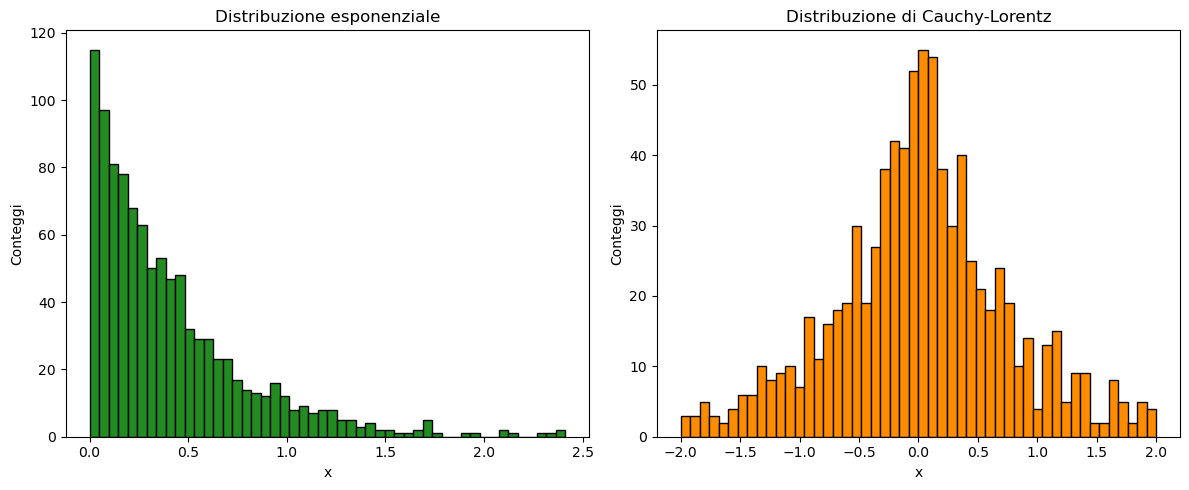

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dati
exp_data = np.loadtxt("esercizio1.2/test_exp.dat")
cl_data = np.loadtxt("esercizio1.2/test_CL.dat")


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Esponenziale
ax[0].hist(exp_data, bins=50, color='forestgreen', edgecolor='black')
ax[0].set_title("Distribuzione esponenziale")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Conteggi")

# Cauchy-Lorentz
ax[1].hist(cl_data, bins=50, range=(-2, 2), edgecolor='black', color='darkorange')
ax[1].set_title("Distribuzione di Cauchy-Lorentz")
ax[1].set_xlabel("x")
ax[1].set_ylabel("Conteggi")

plt.tight_layout()
plt.show()

#### VERIFICA NUMERICA DEL TEOREMA DEL LIMITE CENTRALE

La verifica del Teorema Centrale del Limite è stata effettuata costruendo numericamente la variabile:

$$ S_N = \frac{1}{N}\sum_{i=1}^{N} x_i $$

dove le variabili $x_i$ sono estratte dalle tre distribuzioni considerate, ovvero uniforme, esponenziale e Cauchy-Lorentz. Per ciascuna distribuzione sono stati considerati quattro valori di $N$, ovvero $N = 1, 2, 10, 100$, e per ogni caso sono state generate $10^4$ realizzazioni indipendenti di $S_N$. In questo modo è stato possibile studiare come evolve la distribuzione della media al crescere del numero di variabili sommate.


Per gli istigrammi con $N = 100$, è stata inoltre effettuata una sovrapposizione con la distribuzione teorica attesa: nel caso della distribuzione uniforme ed esponenziale, è stata utilizzata una gaussiana con media e deviazione standard stimate dai dati; nel caso della distribuzione di Cauchy-Lorentz, è stata invece utilizzata una distribuzione di Cauchy con parametri stimati empiricamente: infatti, la distribuzione di Cauchy-Lorentz non ha varianza finita e quindi non rispetta le ipotesi del teorema del limite centrale. 


I risultati mostrano chiaramente che, per le distribuzioni con varianza finita (uniforme ed esponenziale), all’aumentare di $N$ la distribuzione di $S_N$ tende progressivamente a una forma gaussiana, in accordo con il Teorema Centrale del Limite. Al contrario, nel caso della distribuzione di Cauchy-Lorentz, la presenza di varianza infinita impedisce la convergenza a una distribuzione gaussiana e la forma della distribuzione rimane sostanzialmente invariata anche per valori elevati di $N$.


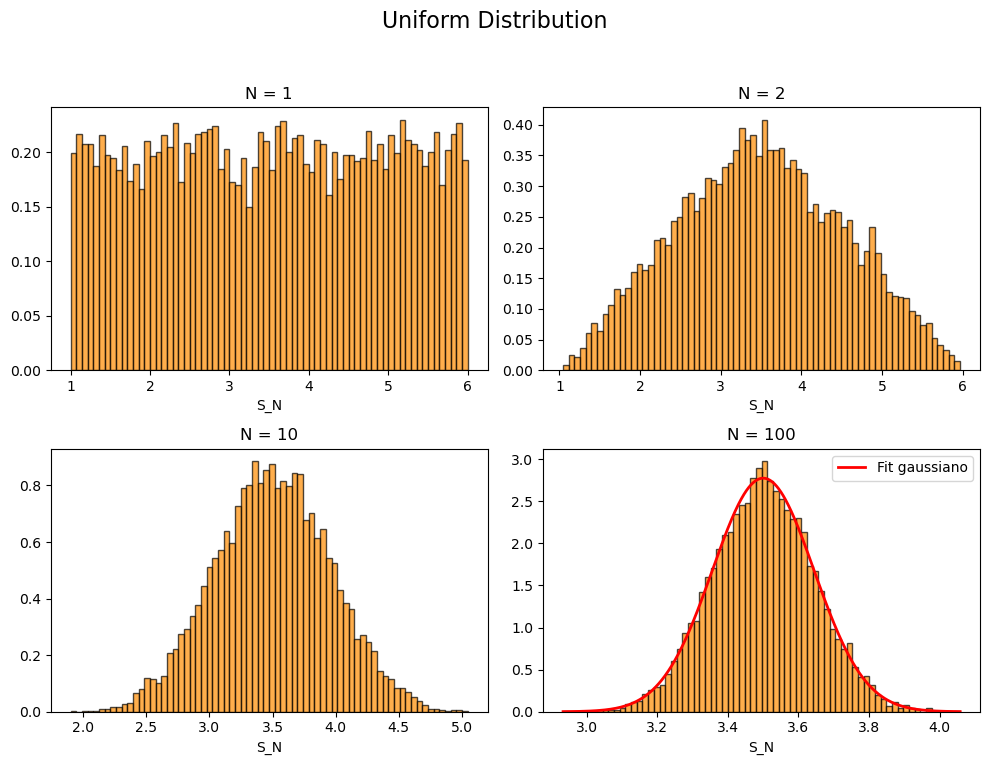

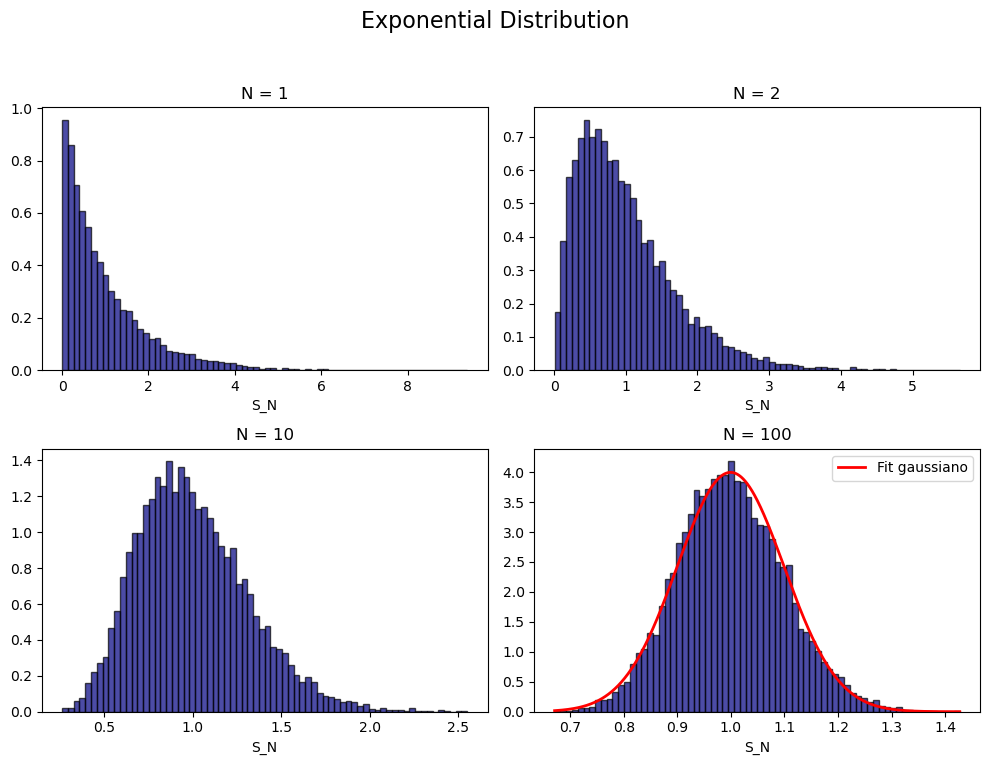

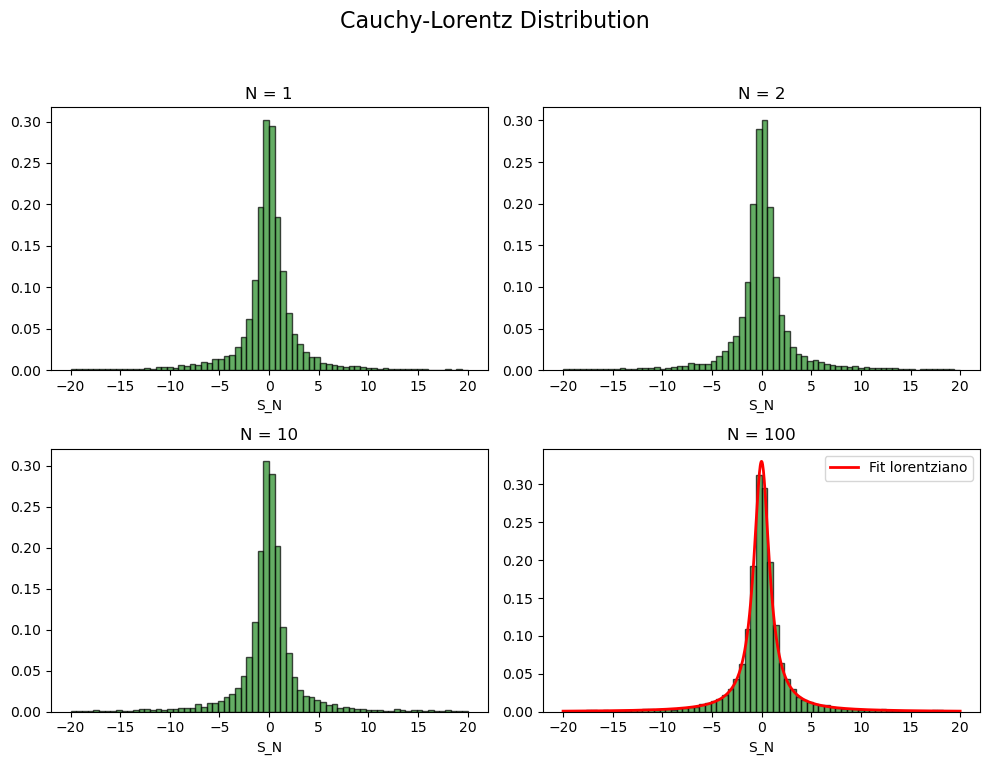

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy

# Lista dei file e distribuzioni
files = ["esercizio1.2/unif.dat", "esercizio1.2/exp.dat", "esercizio1.2/CL.dat"]
distributions = ["Uniform", "Exponential", "Cauchy-Lorentz"]
N_values = [1, 2, 10, 100]

# Parametri istogramma
bins = 70  # numero di bins

for idx, file in enumerate(files):
    data = np.loadtxt(file)
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))


    for j, N in enumerate(N_values):
        SN = data[:, j]
        ax = axs[j // 2, j % 2]

        
        # DEFINIZIONE RANGE ISTOGRAMMA
        if distributions[idx] == "Cauchy-Lorentz":
            hist_range = (-20, 20)
        else:
            hist_range = (np.min(SN), np.max(SN))


        # ISTOGRAMMA NORMALIZZATO
        if distributions[idx] == "Uniform": 
            color = 'darkorange'
        if distributions[idx] == "Exponential": 
            color= 'navy'
        if distributions[idx] == "Cauchy-Lorentz":
            color= 'forestgreen'
        ax.hist(
            SN,
            bins=bins,
            range=hist_range,
            density=True,
            alpha=0.7,
            color=color,
            edgecolor='black'
        )


        # CURVA TEORICA (solo N = 100)
        if N == 100:

            x = np.linspace(hist_range[0], hist_range[1], 1000)

            if distributions[idx] in ["Uniform", "Exponential"]:

                mu = np.mean(SN)
                sigma = np.std(SN)

                y = norm.pdf(x, loc=mu, scale=sigma)
                label = 'Fit gaussiano'

            else:  # Cauchy-Lorentz

                x = np.linspace(-20, 20, 1000)

                mu = np.median(SN)

                # stima robusta della larghezza (IQR / 2)
                gamma = (np.percentile(SN, 75) - np.percentile(SN, 25)) / 2

                y = cauchy.pdf(x, loc=mu, scale=gamma)
                label = 'Fit lorentziano'

            ax.plot(x, y, 'r', lw=2, label = label)

        # LABELS
        ax.set_title(f"N = {N}")
        ax.set_xlabel("S_N")
        ax.set_ylabel("")

  
    # TITOLO FIGURA
    fig.suptitle(f"{distributions[idx]} Distribution", fontsize=16)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.legend()
    plt.show()

 

## **Esercizio 1.3**

In questo esercizio viene simulato numericamente l’esperimento di Buffon, ovvero un metodo probabilistico che permette di stimare il valore della costante $\pi$ a partire da un processo geometrico aleatorio. Il problema consiste nel considerare un ago di lunghezza $L$ lanciato casualmente su un piano attraversato da linee parallele distanti una distanza $d$, con la condizione $d > L$. Ad ogni lancio, l’ago può intersecare oppure no una delle linee del piano. La probabilità teorica che l’ago intersechi una linea è data da:

$$ P = \frac{2L}{\pi d} $$

Questa relazione può essere invertita per ottenere una stima di $\pi$ a partire da un insieme di esperimenti indipendenti. Se l’ago viene lanciato $N_{\text{thr}}$ volte e si osserva un numero $N_{\text{hit}}$ di intersezioni, allora una stima di $\pi$ è data da:

$$ \pi \simeq \frac{2L N_{\text{thr}}}{d N_{\text{hit}}}$$
Nel limite di un numero molto grande di lanci, tale stima converge al valore reale di $\pi$.

L’esperimento viene quindi simulato generando in modo casuale la posizione dell’ago rispetto alle linee e il suo angolo di orientazione. In particolare, si estraggono una distanza $x$ tra il centro dell’ago e la linea più vicina e un angolo $\theta$ uniforme tra 0 e $\pi$. Tuttavia, l’angolo non viene generato esplicitamente: invece di estrarre $\theta$ in un intervallo angolare, si campiona una direzione isotropa nel piano generando un punto uniforme nel disco unitario. Questo si ottiene estraendo due variabili uniformi (rigettandole se il punto non cade nel cerchio unitario) e normalizzandole per ottenere un vettore direzione casuale. In questo modo il valore di $\sin{\theta}$ è ricavato direttamente dalla componente verticale del vettore unitario, senza passare dalla definizione trigonometrica dell’angolo e senza utilizzare esplicitamente $\pi$. La condizione di intersezione è verificata quando la proiezione verticale dell’ago supera la distanza dalla linea, ovvero quando $x < \frac{L}{2}\sin\theta$. Come distanza tra le linee è stata utilizzata $d=1$, mentre come lunghezza dell'ago $L=0.5$. 

Per migliorare la stima statistica e valutare l’incertezza, il metodo viene implementato utilizzando la tecnica del data blocking. Il numero totale di lanci $N = 10^6$ viene suddiviso in $M = 120$ blocchi indipendenti; per ogni blocco viene calcolata una stima locale di $\pi$ e successivamente vengono costruite la media progressiva e l’incertezza statistica della stima.

Di seguito è possibile osservare un grafico che mostra l’evoluzione della stima di $\pi$ in funzione del numero di blocchi, insieme alle barre di errore associate. Questo permette di osservare la convergenza della stima verso il valore teorico e la riduzione dell’incertezza statistica al crescere del numero di misure indipendenti.

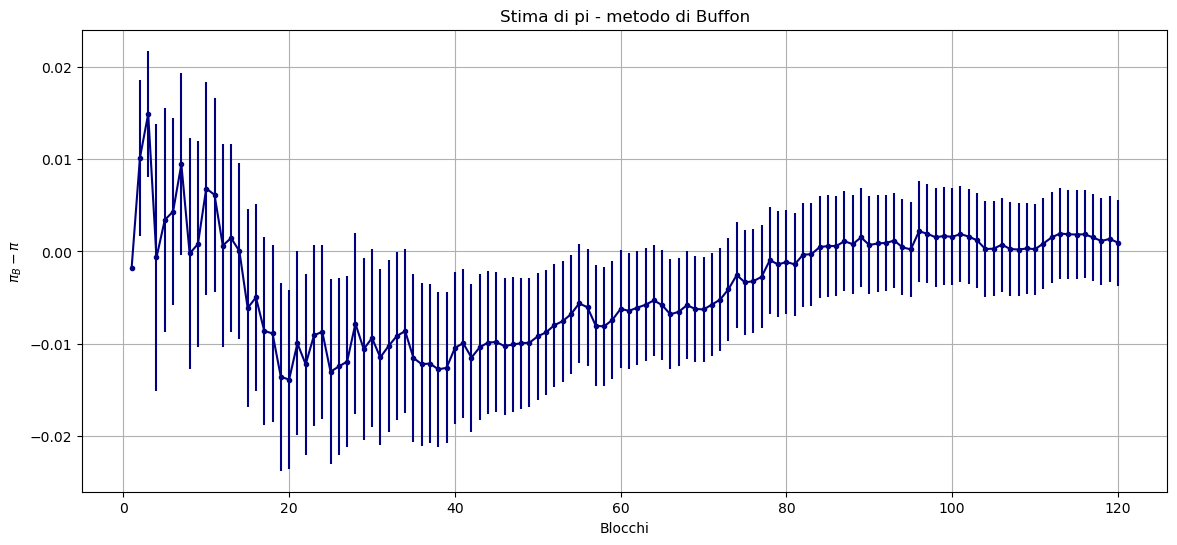

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

data = np.loadtxt("esercizio1.3/data.dat")

x=data[:,0]
y=data[:,1]-math.pi
error=data[:,2]
plt.figure(figsize=(14, 6))
plt.plot(x,y, ".", color='navy')
plt.xlabel("Blocchi")
plt.ylabel(rf"$\pi_B - \pi$")
plt.errorbar(x,y,yerr=error, color='navy')
plt.grid(True)
plt.title("Stima di pi - metodo di Buffon")

plt.show()